# 🚦 EDA — Astram Event Data
> **Dataset:** `Astram event data_anonymized`  
> **Rows:** ~8,173 | **Columns:** 46  
> This notebook performs a comprehensive Exploratory Data Analysis on traffic/road event records captured by the Astram system in Bengaluru.

## 1. Setup & Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'axes.grid':        True,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE = ['#58a6ff','#7ee787','#f78166','#ffa657','#bc8cff','#39d353','#ff7b72','#79c0ff']
sns.set_palette(PALETTE)
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Data

In [6]:
df = pd.read_csv('./Astram_data.csv')
print(f"Shape: {df.shape}")
display(df.head())

Shape: (8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


## 3. Basic Info & Data Types

In [7]:
print("=== Data Types ===")
print(df.dtypes.to_string())

=== Data Types ===
id                           str
event_type                   str
latitude                 float64
longitude                float64
endlatitude              float64
endlongitude             float64
address                      str
end_address                  str
event_cause                  str
requires_road_closure       bool
start_datetime               str
end_datetime                 str
status                       str
authenticated                str
modified_datetime            str
map_file                 float64
direction                    str
description                  str
veh_type                     str
veh_no                       str
corridor                     str
priority                     str
cargo_material               str
reason_breakdown             str
age_of_truck             float64
created_date                 str
route_path                   str
client_id                  int64
created_by_id                str
last_modified_by_id     

In [8]:
print("=== Memory Usage ===")
print(df.memory_usage(deep=True).to_string())

=== Memory Usage ===
Index                        132
id                        482207
event_type                473100
latitude                   65384
longitude                  65384
endlatitude                65384
endlongitude               65384
address                  1172954
end_address               343921
event_cause               515688
requires_road_closure       8173
start_datetime            612015
end_datetime              280705
status                    449657
authenticated             423989
modified_datetime         636599
map_file                   65384
direction                 262598
description               839735
veh_type                  385221
veh_no                    398344
corridor                  500173
priority                  429986
cargo_material            268958
reason_breakdown          270806
age_of_truck               65384
created_date              636527
route_path                367199
client_id                  65384
created_by_id         

## 4. Missing Value Analysis

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
display(missing_df)

,Missing Count,Missing %
map_file,8173,100.00
meta_data,8173,100.00
comment,8173,100.00
direction,8130,99.47
resolved_at_longitude,8099,99.09
resolved_at_latitude,8099,99.09
resolved_at_address,8099,99.09
resolved_datetime,8099,99.09
resolved_by_id,8099,99.09
citizen_accident_id,8045,98.43


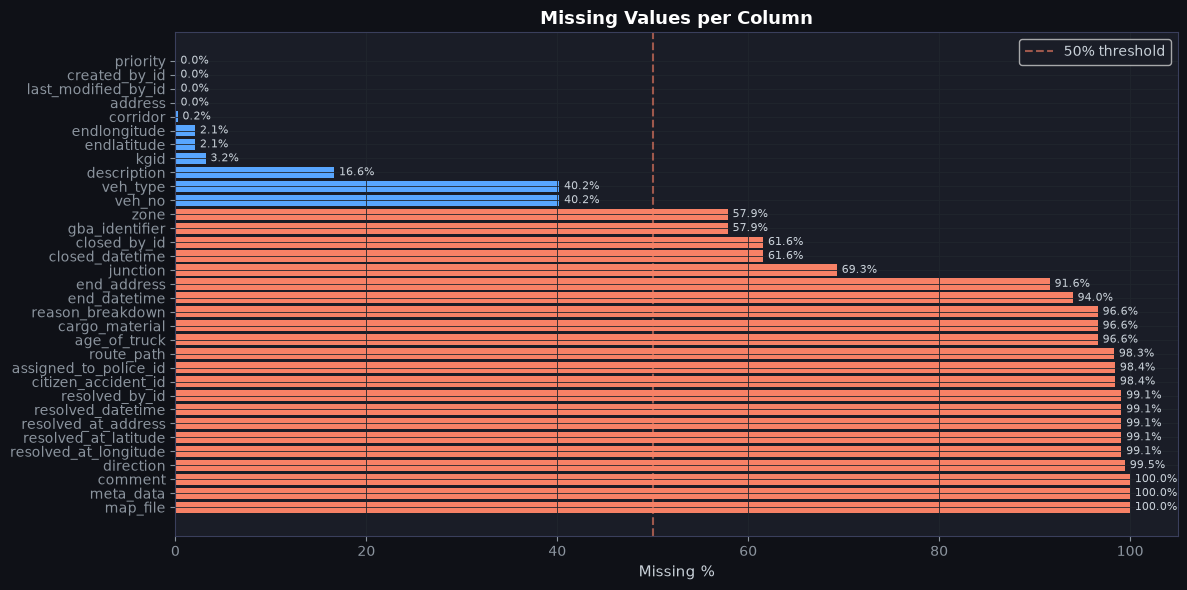

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = [PALETTE[0] if p < 50 else PALETTE[2] for p in missing_df['Missing %']]
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=colors, edgecolor='none')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column', fontweight='bold', color='white')
ax.axvline(50, color=PALETTE[2], linestyle='--', alpha=0.6, label='50% threshold')
ax.legend()
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=8, color='#c9d1d9')
plt.tight_layout()
plt.show()

## 5. Datetime Parsing & Feature Engineering

In [11]:
dt_cols = ['start_datetime','end_datetime','modified_datetime','created_date',
           'closed_datetime','resolved_datetime']
for col in dt_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

df['start_date']  = df['start_datetime'].dt.date
df['start_hour']  = df['start_datetime'].dt.hour
df['start_dow']   = df['start_datetime'].dt.day_name()
df['start_month'] = df['start_datetime'].dt.month_name()
df['start_year']  = df['start_datetime'].dt.year

# Duration in minutes
df['duration_min'] = (
    (df['end_datetime'] - df['start_datetime'])
    .dt.total_seconds() / 60
)
print("Feature engineering complete.")
print(df[['start_datetime','duration_min']].describe())

Feature engineering complete.
       duration_min
count  3.820000e+02
mean   9.032457e+03
std    1.077418e+05
min   -1.340008e+03
25%    2.267883e+00
50%    3.250827e+02
75%    7.824316e+02
max    2.051059e+06


## 6. Event Type Analysis

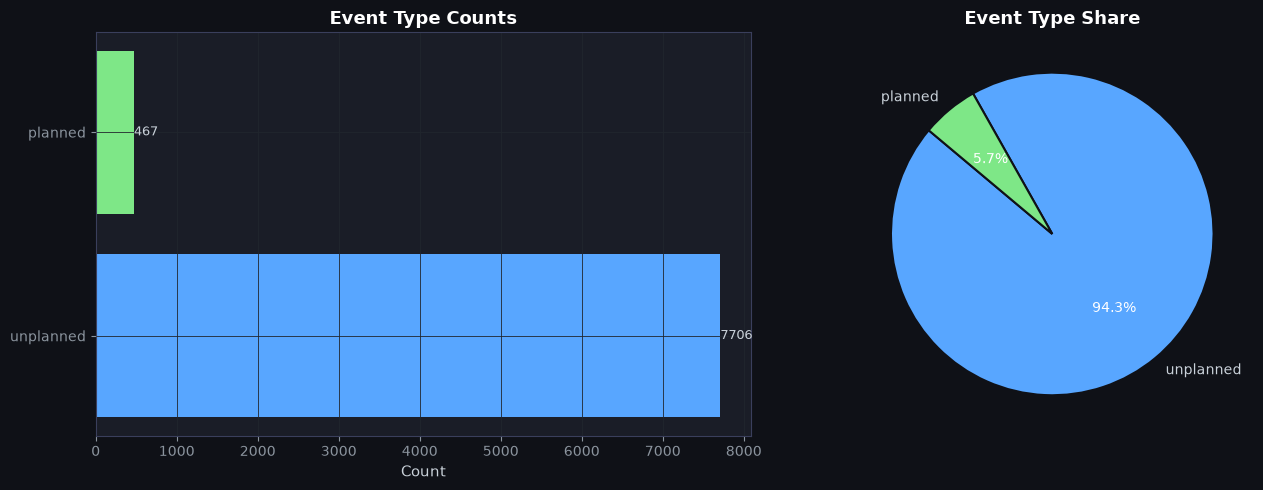

In [12]:
et = df['event_type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].barh(et.index, et.values, color=PALETTE[:len(et)], edgecolor='none')
axes[0].set_title('Event Type Counts', fontweight='bold', color='white')
axes[0].set_xlabel('Count')
for i, (v, label) in enumerate(zip(et.values, et.index)):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Pie
wedges, texts, autotexts = axes[1].pie(
    et.values, labels=et.index, autopct='%1.1f%%',
    colors=PALETTE[:len(et)], startangle=140,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 1.5}
)
for t in autotexts: t.set_color('white')
axes[1].set_title('Event Type Share', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## 7. Event Status Distribution

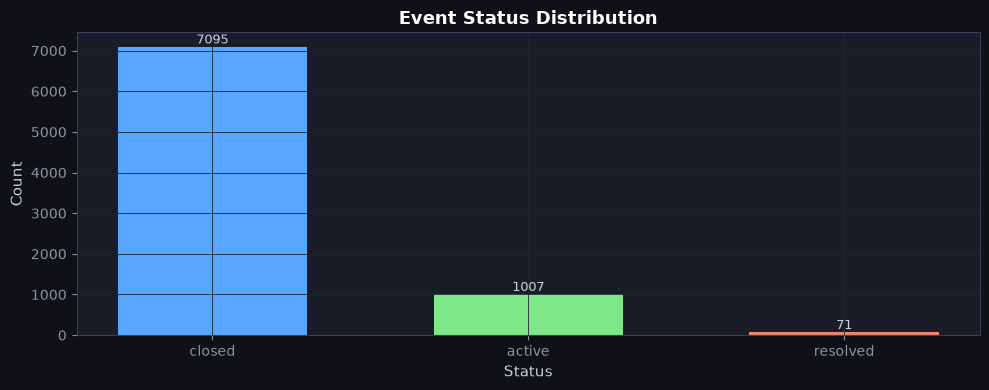

In [13]:
status_counts = df['status'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(status_counts.index, status_counts.values,
              color=PALETTE[:len(status_counts)], edgecolor='none', width=0.6)
ax.set_title('Event Status Distribution', fontweight='bold', color='white')
ax.set_xlabel('Status'); ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Temporal Analysis

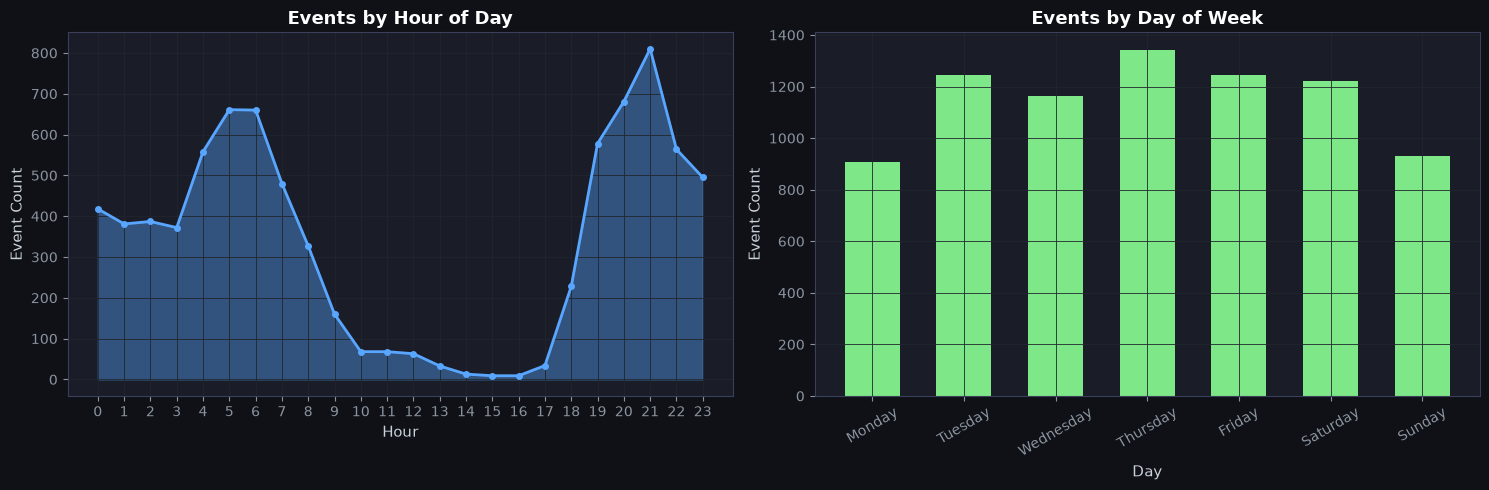

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hourly
hourly = df.groupby('start_hour').size()
axes[0].fill_between(hourly.index, hourly.values, alpha=0.4, color=PALETTE[0])
axes[0].plot(hourly.index, hourly.values, color=PALETTE[0], linewidth=2, marker='o', markersize=4)
axes[0].set_title('Events by Hour of Day', fontweight='bold', color='white')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Event Count')
axes[0].set_xticks(range(0, 24))

# Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df['start_dow'].value_counts().reindex(dow_order)
axes[1].bar(dow.index, dow.values, color=PALETTE[1], edgecolor='none', width=0.6)
axes[1].set_title('Events by Day of Week', fontweight='bold', color='white')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Event Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

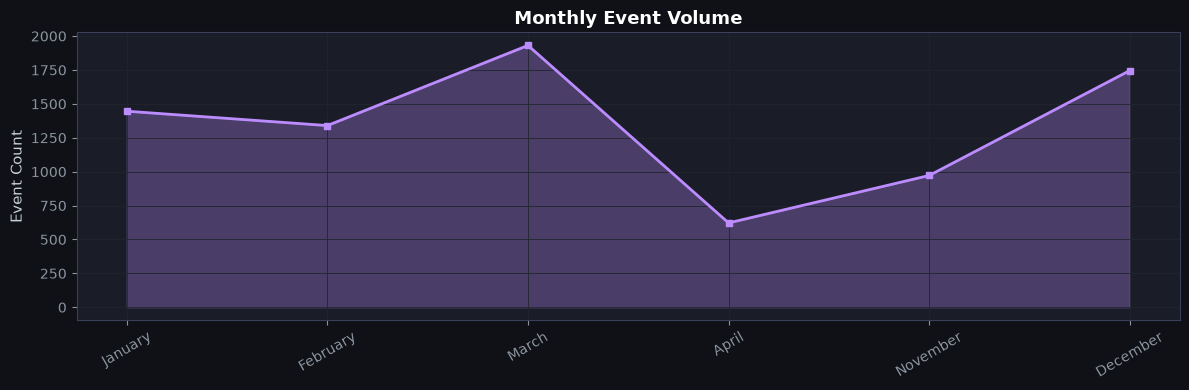

In [15]:
# Monthly trend
monthly = df.groupby('start_month').size()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = monthly.reindex([m for m in month_order if m in monthly.index])

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.3, color=PALETTE[4])
ax.plot(range(len(monthly)), monthly.values, color=PALETTE[4], linewidth=2, marker='s', markersize=5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=30)
ax.set_title('Monthly Event Volume', fontweight='bold', color='white')
ax.set_ylabel('Event Count')
plt.tight_layout()
plt.show()

## 9. Event Cause Analysis

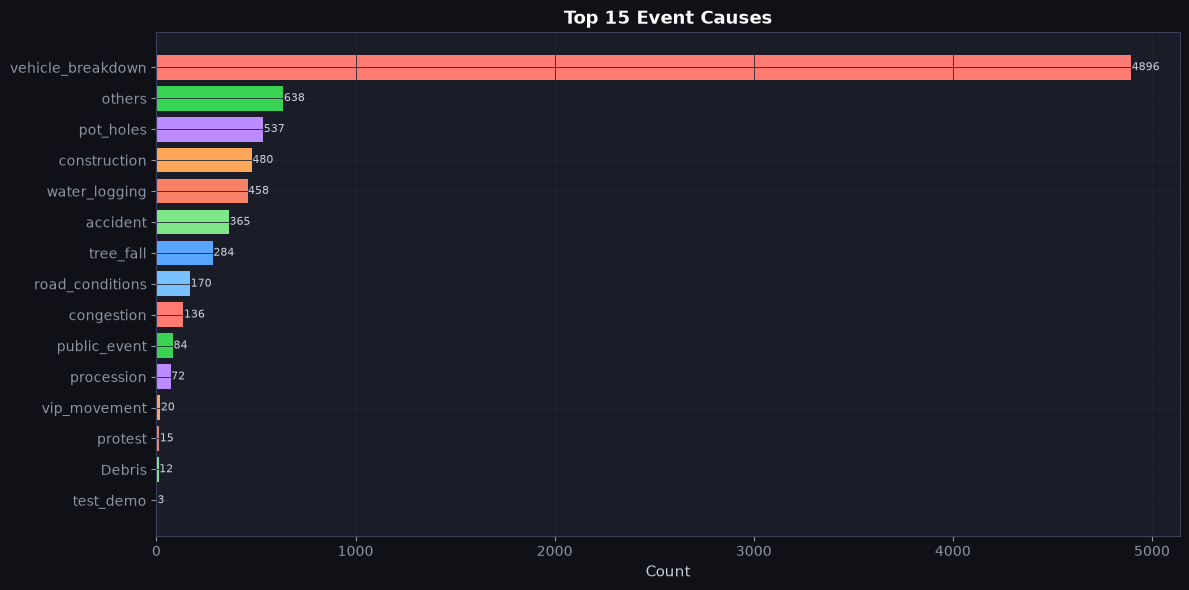

In [16]:
if 'event_cause' in df.columns:
    cause = df['event_cause'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(cause.index[::-1], cause.values[::-1],
                   color=sns.color_palette(PALETTE, len(cause)), edgecolor='none')
    ax.set_title('Top 15 Event Causes', fontweight='bold', color='white')
    ax.set_xlabel('Count')
    for bar in bars:
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                str(int(bar.get_width())), va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Vehicle Type Analysis

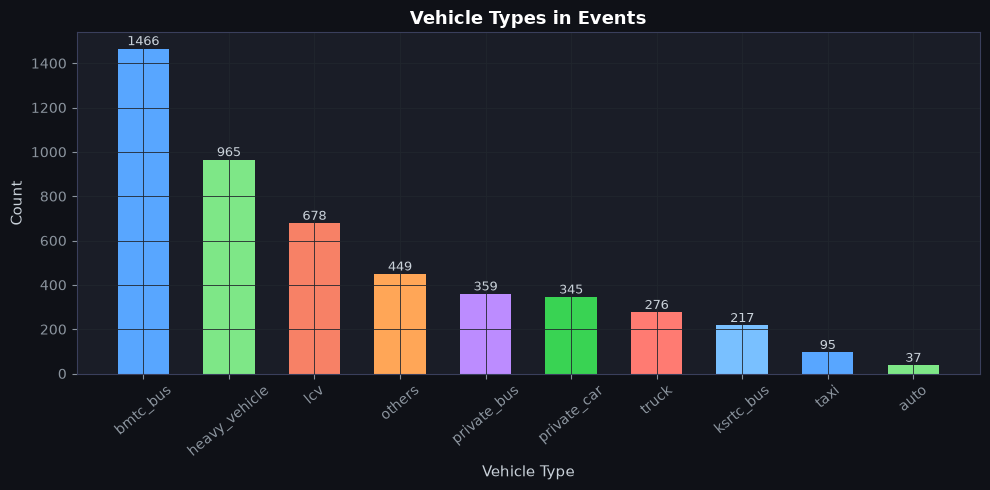

In [17]:
if 'veh_type' in df.columns:
    vt = df['veh_type'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(vt.index, vt.values, color=PALETTE[:len(vt)], edgecolor='none', width=0.6)
    ax.set_title('Vehicle Types in Events', fontweight='bold', color='white')
    ax.set_xlabel('Vehicle Type'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=40)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

## 11. Priority Analysis

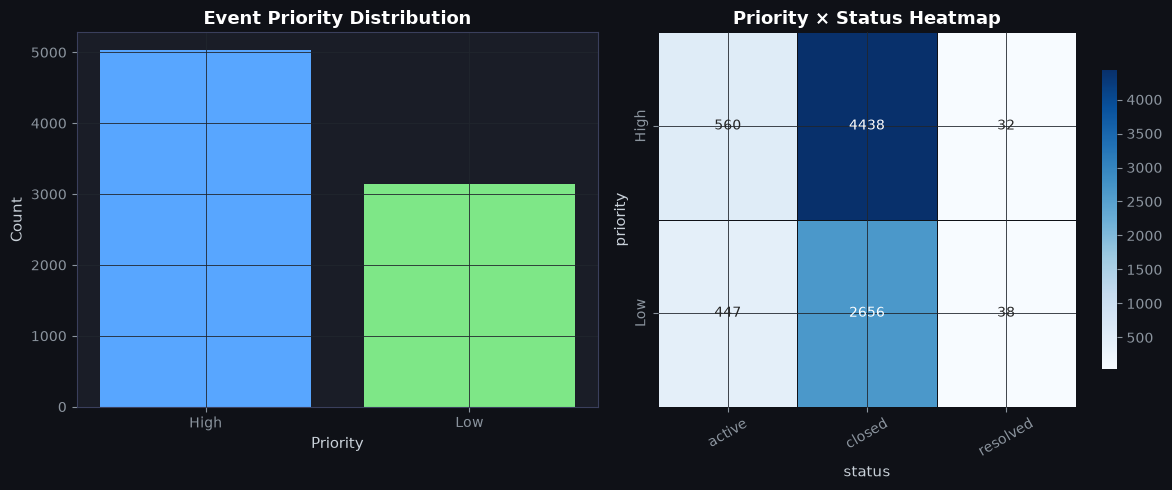

In [18]:
if 'priority' in df.columns:
    pri = df['priority'].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].bar(pri.index.astype(str), pri.values, color=PALETTE[:len(pri)], edgecolor='none')
    axes[0].set_title('Event Priority Distribution', fontweight='bold', color='white')
    axes[0].set_xlabel('Priority'); axes[0].set_ylabel('Count')

    # Priority × Status heatmap
    ps = pd.crosstab(df['priority'], df['status'])
    sns.heatmap(ps, ax=axes[1], cmap='Blues', annot=True, fmt='d',
                linewidths=0.5, linecolor='#0f1117',
                cbar_kws={'shrink': 0.8})
    axes[1].set_title('Priority × Status Heatmap', fontweight='bold', color='white')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

## 12. Event Duration Distribution

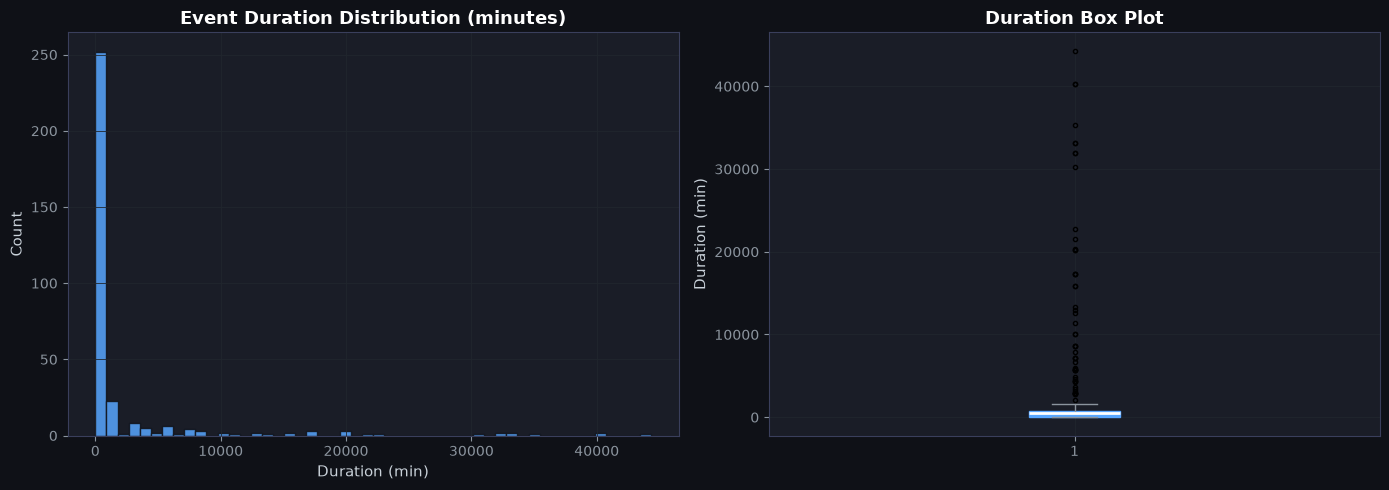

Median duration: 476.9 min | Mean: 2564.9 min | 95th pct: 16638.7 min


In [19]:
dur = df['duration_min'].dropna()
dur = dur[(dur >= 0) & (dur < dur.quantile(0.99))]  # remove outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dur, bins=50, color=PALETTE[0], edgecolor='#0f1117', alpha=0.85)
axes[0].set_title('Event Duration Distribution (minutes)', fontweight='bold', color='white')
axes[0].set_xlabel('Duration (min)'); axes[0].set_ylabel('Count')

axes[1].boxplot(dur, vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], color=PALETTE[0]),
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#8b949e'),
                capprops=dict(color='#8b949e'),
                flierprops=dict(marker='o', color=PALETTE[2], markersize=3))
axes[1].set_title('Duration Box Plot', fontweight='bold', color='white')
axes[1].set_ylabel('Duration (min)')
plt.tight_layout()
plt.show()
print(f"Median duration: {dur.median():.1f} min | Mean: {dur.mean():.1f} min | 95th pct: {dur.quantile(0.95):.1f} min")

## 13. Requires Road Closure

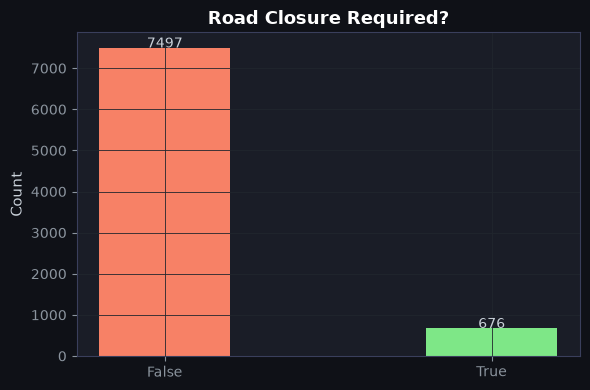

In [20]:
if 'requires_road_closure' in df.columns:
    rc = df['requires_road_closure'].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(rc.index.astype(str), rc.values, color=[PALETTE[2], PALETTE[1]], edgecolor='none', width=0.4)
    ax.set_title('Road Closure Required?', fontweight='bold', color='white')
    ax.set_ylabel('Count')
    for i, v in enumerate(rc.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

## 14. Zone & Police Station Analysis

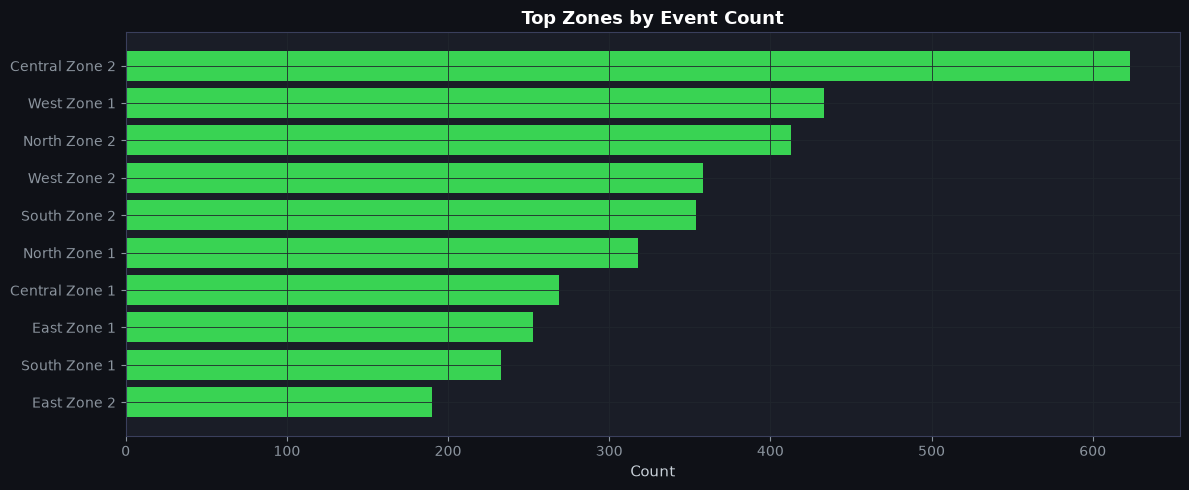

In [21]:
if 'zone' in df.columns:
    zone = df['zone'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(zone.index[::-1], zone.values[::-1], color=PALETTE[5], edgecolor='none')
    ax.set_title('Top Zones by Event Count', fontweight='bold', color='white')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

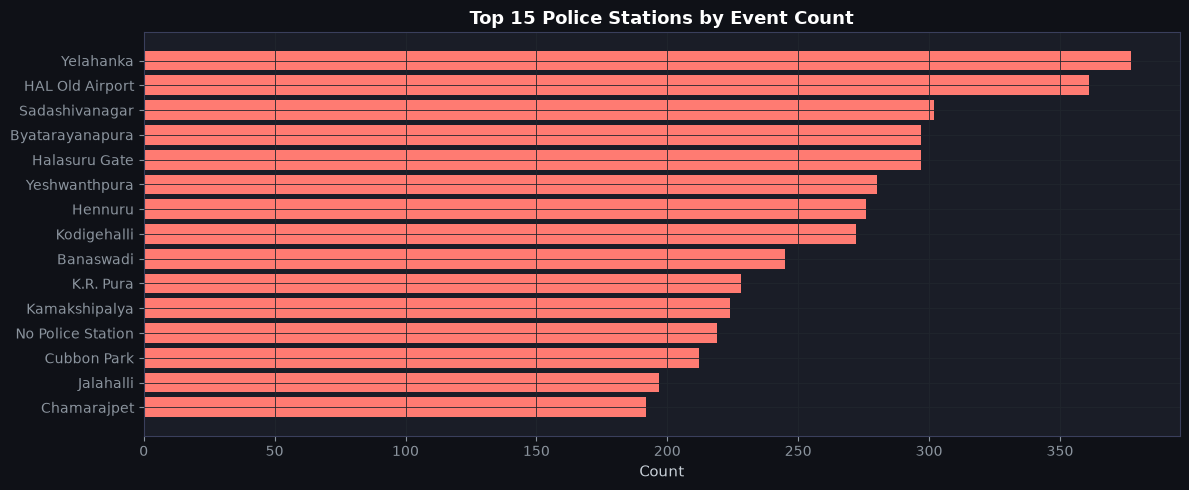

In [22]:
if 'police_station' in df.columns:
    ps_top = df['police_station'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(ps_top.index[::-1], ps_top.values[::-1], color=PALETTE[6], edgecolor='none')
    ax.set_title('Top 15 Police Stations by Event Count', fontweight='bold', color='white')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

## 15. Geographic Distribution (Lat/Lon)

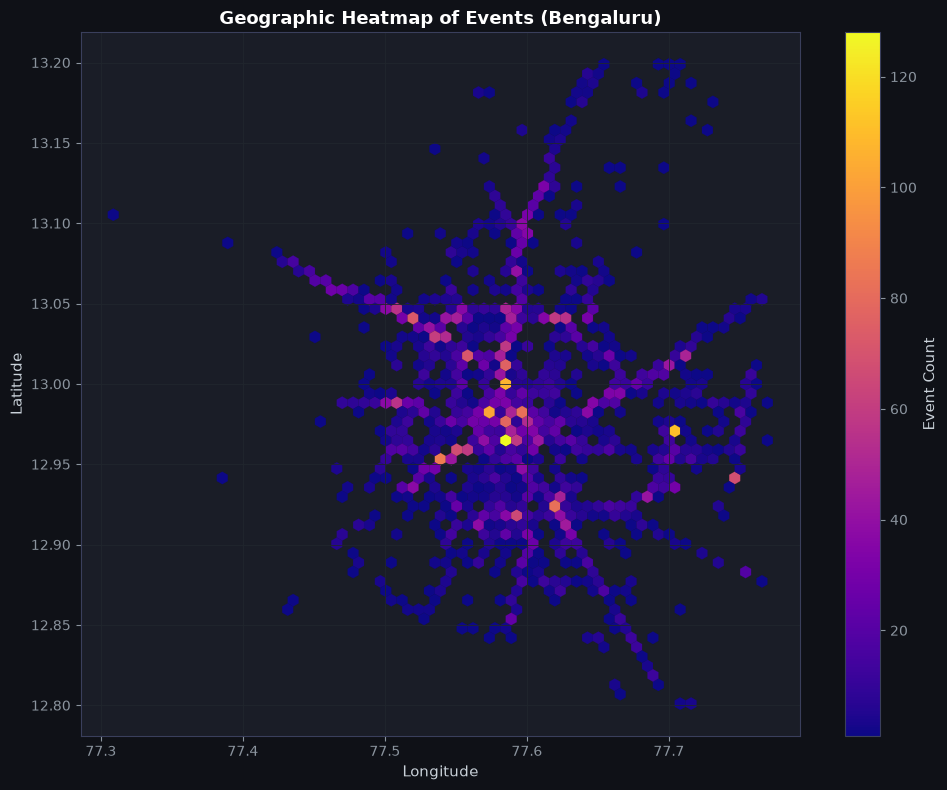

In [23]:
geo = df[['latitude','longitude']].dropna()
geo = geo[(geo['latitude'].between(12.7, 13.2)) & (geo['longitude'].between(77.3, 77.9))]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.hexbin(geo['longitude'], geo['latitude'], gridsize=60,
                    cmap='plasma', mincnt=1, linewidths=0.1)
plt.colorbar(scatter, ax=ax, label='Event Count')
ax.set_title('Geographic Heatmap of Events (Bengaluru)', fontweight='bold', color='white')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 16. Correlation Heatmap (Numeric Columns)

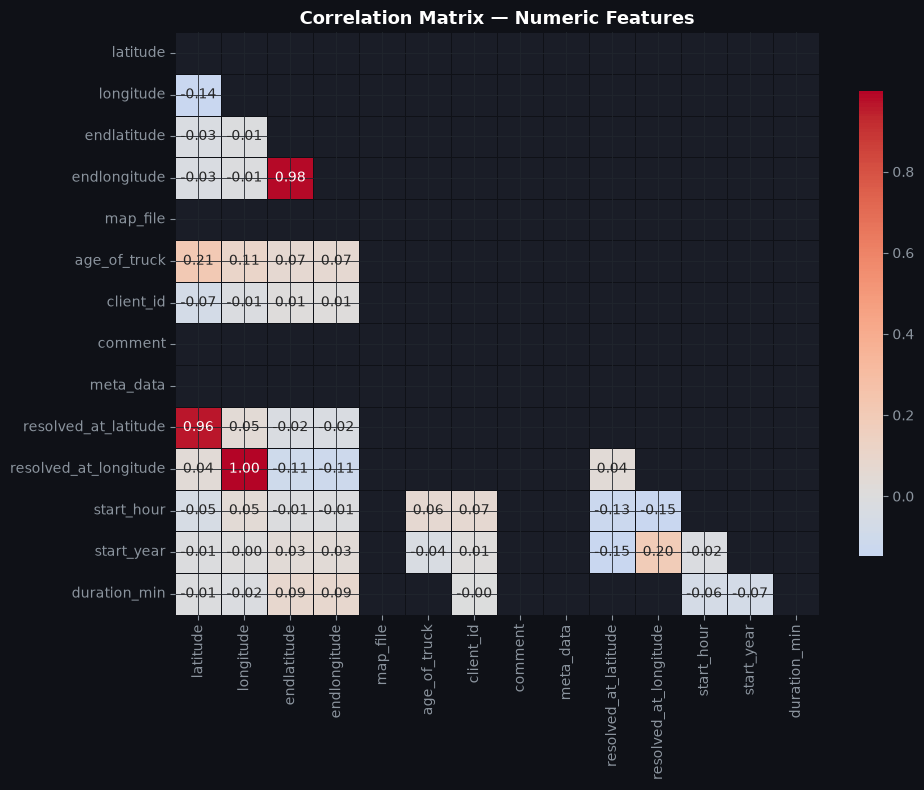

In [24]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0f1117', ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', color='white')
plt.tight_layout()
plt.show()

## 17. Summary Statistics

In [25]:
print("=== Numerical Summary ===")
display(df.describe().T)

=== Numerical Summary ===


,count,mean,std,min,25%,50%,75%,max
latitude,8173.0,12.987076,0.060109,12.801041,12.951635,12.982847,13.026867,1.326751e+01
longitude,8173.0,77.596034,0.061193,77.308731,77.556747,77.589460,77.625853,7.776940e+01
endlatitude,8004.0,1.128050,3.736845,0.000000,0.000000,0.000000,0.000000,5.986013e+01
endlongitude,8004.0,6.678011,21.761316,0.000000,0.000000,0.000000,0.000000,8.072069e+01
map_file,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_of_truck,276.0,235.518116,634.059816,0.000000,5.000000,10.000000,15.000000,2.026000e+03
client_id,8173.0,1.009788,0.098457,1.000000,1.000000,1.000000,1.000000,2.000000e+00
comment,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
meta_data,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolved_at_latitude,74.0,13.002599,0.091377,12.841568,12.947656,12.983715,13.019590,1.325730e+01


In [26]:
print("=== Categorical Summary ===")
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols[:8]:
    print(f"\n[{c}] unique={df[c].nunique()} | top values:")
    print(df[c].value_counts().head(5).to_string())

=== Categorical Summary ===

[id] unique=8173 | top values:
id
FKID000000    1
FKID000001    1
FKID000002    1
FKID000003    1
FKID000004    1

[event_type] unique=2 | top values:
event_type
unplanned    7706
planned       467

[address] unique=3089 | top values:
address
Outer Ring Road, Karthik Nagar, Marathahalli, Bengaluru, Karnataka. Pin-560037 (India)                  88
2nd Cross Road, MTB Area, Jayanagar, Bengaluru, Karnataka. Pin-560041 (India)                           44
Sankey Road, RV Layout, Seshadripuram, Bengaluru, Karnataka. Pin-560020 (India)                         36
MBT Road, Block 5 Stage 1, HBR Layout, Bengaluru, Karnataka. Pin-560043 (India)                         35
Sankey Road, MD Nanjundaswamy Circle, Rajamahal Guttahalli, Bengaluru, Karnataka. Pin-560003 (India)    34

[end_address] unique=561 | top values:
end_address
Outer Ring Road, CQAE Staff Quarters, Yeshwanthpur, Bengaluru, Karnataka. Pin-560022 (India)                6
Varthuru Road, Deja View Homes,

In [ ]:
df.latitude.min()